# 16. Simplified SIR Model

$$
\begin{align}
\frac{dS}{dt} &= - \frac{\gamma R_0}{N} S I, \\
\frac{dI}{dt} &= \gamma \left( R_0 \frac{S}{N} - 1\right) I, \\
\frac{dR}{dI} &= \gamma I.
\end{align}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Model definition

In [2]:
def SIR_Fast(u, t, N, gamma, R0):
    S, I, R = u
    beta = R0 * gamma / N
    dS = - beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I 
    return [dS, dI, dR]

## Steady states

There is an infinite number of steady states. The only condition is that $I=0$.

Text(0, 0.5, 'Normalized Population Size')

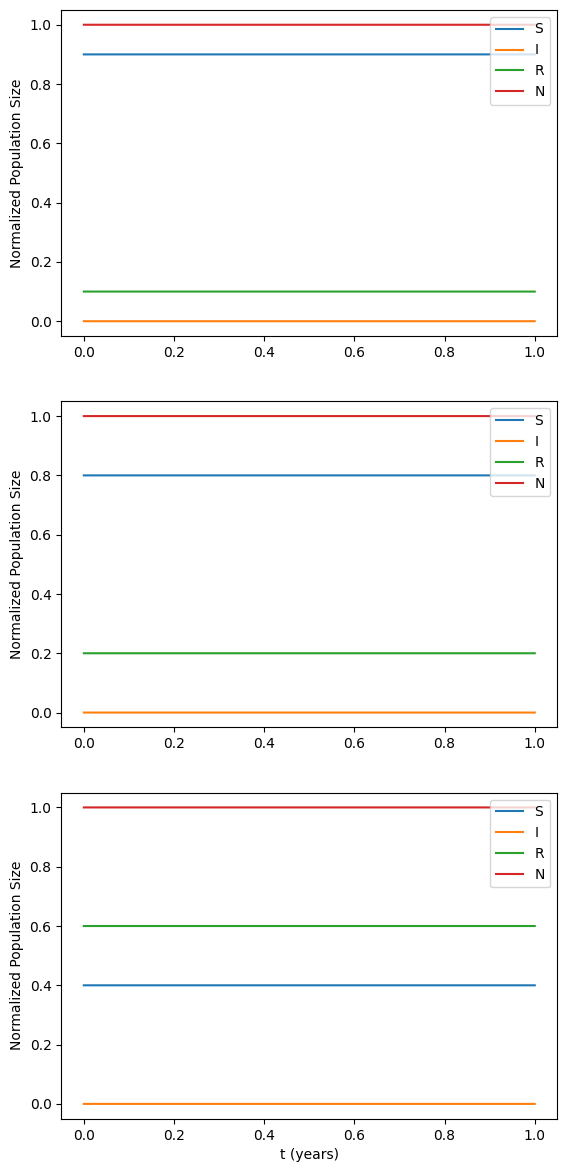

In [32]:
N = 1
R0 = 4
gamma = 1/2
t = np.linspace(0, 52, 20001)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6.4, 4.8*3))

u = odeint(SIR_Fast, [.9, 0, .1], t, args=(N, gamma, R0))
ax[0].plot(t/52., u[:,0], color='C0', label="S")
ax[0].plot(t/52., u[:,1], color='C1', label="I")
ax[0].plot(t/52., u[:,2], color='C2', label="R")
ax[0].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[0].legend(loc="upper right")
#ax[0].set_xlabel("t (years)", fontsize=16)
ax[0].set_ylabel("Normalized Population Size")

u = odeint(SIR_Fast, [.8, 0, .2], t, args=(N, gamma, R0))
ax[1].plot(t/52., u[:,0], color='C0', label="S")
ax[1].plot(t/52., u[:,1], color='C1', label="I")
ax[1].plot(t/52., u[:,2], color='C2', label="R")
ax[1].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[1].legend(loc="upper right")
#ax[1].set_xlabel("t (years)", fontsize=16)
ax[1].set_ylabel("Normalized Population Size")

u = odeint(SIR_Fast, [.4, 0, .6], t, args=(N, gamma, R0))
ax[2].plot(t/52., u[:,0], color='C0', label="S")
ax[2].plot(t/52., u[:,1], color='C1', label="I")
ax[2].plot(t/52., u[:,2], color='C2', label="R")
ax[2].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[2].legend(loc="upper right")
ax[2].set_xlabel("t (years)")
ax[2].set_ylabel("Normalized Population Size")

## Herd immunity

$R_e(0) = R_0 S / N < 1$, or equivalently $S < N/R_0$, is the condition for not having an epidemic outbreak.

Text(0, 0.5, 'Normalized Population Size')

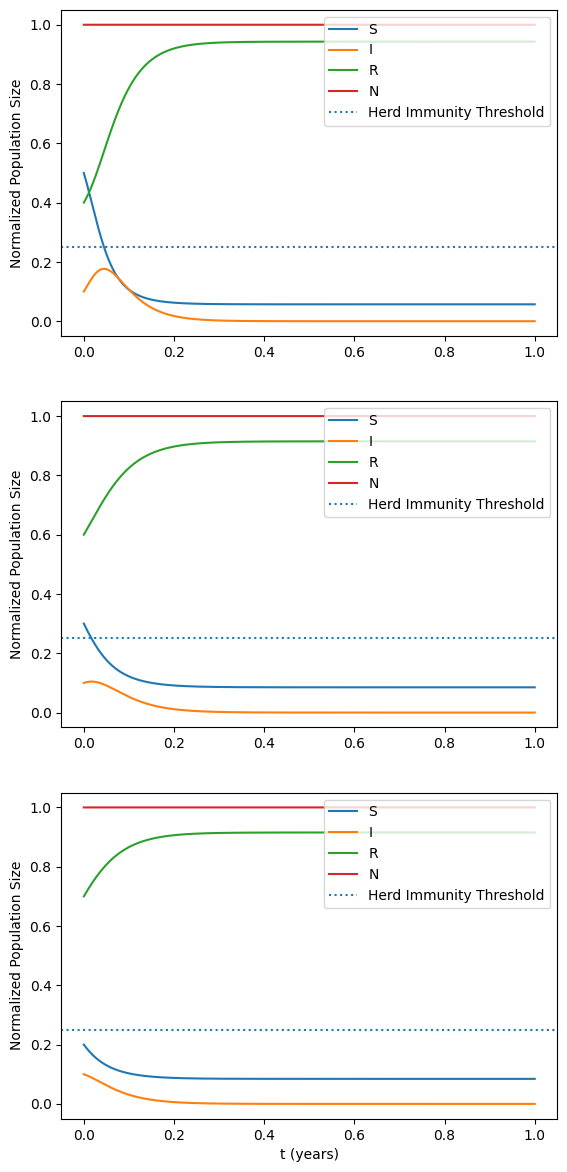

In [31]:
N = 1
R0 = 4
gamma = 1/2
t = np.linspace(0, 52, 20001)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6.4, 4.8*3))

u = odeint(SIR_Fast, [.5, 0.1, 0.4], t, args=(N, gamma, R0))
ax[0].plot(t/52., u[:,0], color='C0', label="S")
ax[0].plot(t/52., u[:,1], color='C1', label="I")
ax[0].plot(t/52., u[:,2], color='C2', label="R")
ax[0].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[0].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[0].legend(loc="upper right")
#ax[0].set_xlabel("t (years)", fontsize=16)
ax[0].set_ylabel("Normalized Population Size")

u = odeint(SIR_Fast, [.3, 0.1, .6], t, args=(N, gamma, R0))
ax[1].plot(t/52., u[:,0], color='C0', label="S")
ax[1].plot(t/52., u[:,1], color='C1', label="I")
ax[1].plot(t/52., u[:,2], color='C2', label="R")
ax[1].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[1].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[1].legend(loc="upper right")
#ax[1].set_xlabel("t (years)", fontsize=16)
ax[1].set_ylabel("Normalized Population Size")

u = odeint(SIR_Fast, [.2, 0.1, .7], t, args=(N, gamma, R0))
ax[2].plot(t/52., u[:,0], color='C0', label="S")
ax[2].plot(t/52., u[:,1], color='C1', label="I")
ax[2].plot(t/52., u[:,2], color='C2', label="R")
ax[2].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[2].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[2].legend(loc="upper right")
ax[2].set_xlabel("t (years)")
ax[2].set_ylabel("Normalized Population Size")

## Epidemic outbreak peak

The peak of an epidemic outbreak accurs at $R_e(t) = R_0 S(t)/N = 1$. Equivalently, at $S(t) = N/R_0$

Text(0, 0.5, 'Normalized Population Size')

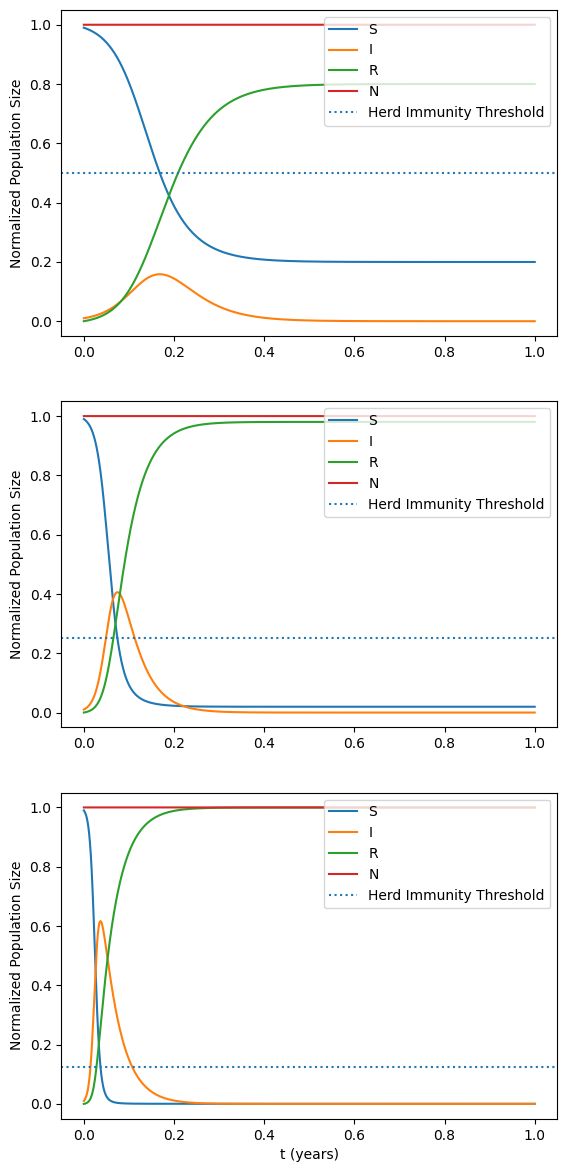

In [29]:
N = 1
gamma = 1/2
t = np.linspace(0, 52, 20001)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6.4, 4.8*3))

R0 = 2
u = odeint(SIR_Fast, [.99, 0.01, 0], t, args=(N, gamma, R0))
ax[0].plot(t/52., u[:,0], color='C0', label="S")
ax[0].plot(t/52., u[:,1], color='C1', label="I")
ax[0].plot(t/52., u[:,2], color='C2', label="R")
ax[0].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[0].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[0].legend(loc="upper right")
#ax[0].set_xlabel("t (years)", fontsize=16)
ax[0].set_ylabel("Normalized Population Size")

R0 = 4
u = odeint(SIR_Fast, [.99, 0.01, 0], t, args=(N, gamma, R0))
ax[1].plot(t/52., u[:,0], color='C0', label="S")
ax[1].plot(t/52., u[:,1], color='C1', label="I")
ax[1].plot(t/52., u[:,2], color='C2', label="R")
ax[1].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[1].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[1].legend(loc="upper right")
#ax[1].set_xlabel("t (years)", fontsize=16)
ax[1].set_ylabel("Normalized Population Size")

R0 = 8
u = odeint(SIR_Fast, [.99, 0.01, 0], t, args=(N, gamma, R0))
ax[2].plot(t/52., u[:,0], color='C0', label="S")
ax[2].plot(t/52., u[:,1], color='C1', label="I")
ax[2].plot(t/52., u[:,2], color='C2', label="R")
ax[2].plot(t/52., np.sum(u, axis=1), color='C3', label="N")
ax[2].axhline(y=N/R0, color='C0', linestyle=':', label='Herd Immunity Threshold')
ax[2].legend(loc="upper right")
ax[2].set_xlabel("t (years)")
ax[2].set_ylabel("Normalized Population Size")

## Confination

Assuming that confination decreases $R_0$, we can assume that the effective basic reproduction number is $R_0^{eff} = R_0 (1 - c(t))$, where $c(t)$ measures the effectiveness of confination. What would be the optimal strategy (the optimal function $c(t)$) to reach herd immunity in the minimum time, while keeping the number of infected individuals under control.

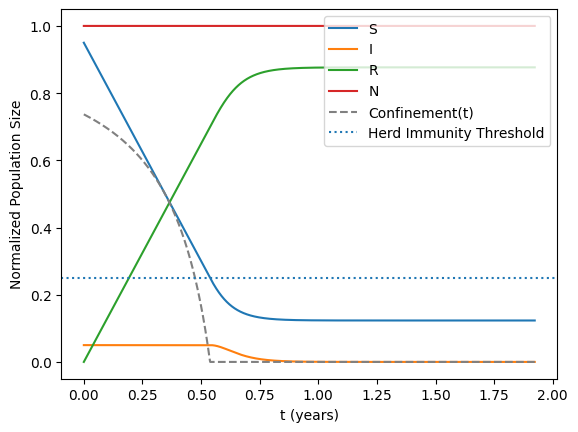

In [30]:
def SIR_Fast_Opt(u, t, N, gamma, R0):
    S, I, R = u
    beta = (1 - c(S,N,R0)) * R0 * gamma / N
    dS = - beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I 
    return [dS, dI, dR]

def c(S, N, R0):
    if S > N/R0:
        return 1- N/R0/S
    else:
        return 0.0

N = 1
R0 = 4
gamma = 1/2
    
t = np.linspace(0, 100, 20001)
    
u = odeint(SIR_Fast_Opt, [.95, .05, 0], t, args=(N, gamma, R0))

fig, ax = plt.subplots()
ax.plot(t/52., u[:,0], color='C0', label="S")
ax.plot(t/52., u[:,1], color='C1', label="I")
ax.plot(t/52., u[:,2], color='C2', label="R")
ax.plot(t/52., np.sum(u, axis=1), color='C3', label="N")

conf = np.zeros_like(t)
for i, tt in enumerate(t):
    conf[i] = c(u[i,0], N, R0)
ax.plot(t/52, conf, color='gray', linestyle='--', label="Confinement(t)")
ax.axhline(N/R0, color='C0', linestyle=':', label="Herd Immunity Threshold")

ax.legend(loc="upper right")
ax.set_xlabel("t (years)")
ax.set_ylabel("Normalized Population Size")
ax.tick_params(axis='both')
